In [1]:

%reset -f 
from nn_models.SEIR_pyro import SEIR_pyro, SEIR_Model
import pyro.distributions as dist
from samplers.SEIR_mcmc_base import SEIR_mcmc_base
from BNN import pyro_SVI
import pyro
import matplotlib.pyplot as plt
import numpy as np
from epidemic_model import SEIR_Model, Epidemic_Model
from utils.utils import load_data, parser
import sys
import torch
from joblib import dump, load
from time import time
from torchdiffeq import odeint as torch_odeint

from scipy import stats



Data loaded from file:  ./data/Smoothed_Cases_Third_Wave.csv


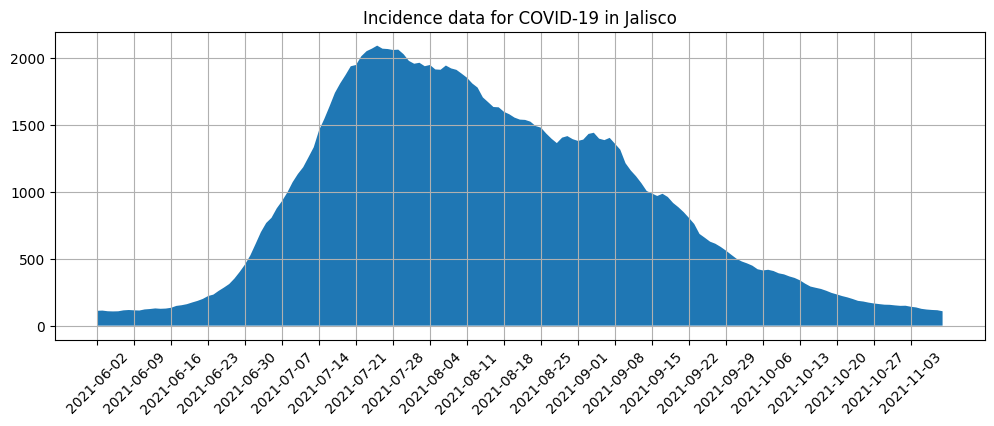

In [2]:
args = ['configuration_file_bnn.cfg']

fname_conf = args[0]
params = parser(fname_conf)

times, data, dates = load_data(params['fname'])

print('Data loaded from file: ', params['fname'])

# plotting data
plt.figure(figsize=(12,4))
plt.fill_between(dates,data, label='Incidence data')
plt.xticks(dates[::7],rotation=45)
plt.title('Incidence data for COVID-19 in Jalisco')
plt.grid()
plt.show()


In [3]:
N = params["N"]
print(f'Data willl be normalized by factor {N}')

E0 = data[0]*5 
I0 = params['I0']
R0 = 0
S0 = N - E0 - I0 - R0

x0 = [S0,E0,I0,R0]

beta = params['beta_0']
sigma = params['sigma_0']
gamma = params['gamma_0']
iterations = params['iterations']
reload_flag = (params['reload'] == 1)
out_file = params['outfile']
outpath = params['outpath']

Data willl be normalized by factor 170000


In [4]:
if reload_flag :
    model = load(outpath+'/SVI/'+out_file)
    model.outpath = outpath

In [5]:
if not reload_flag :
    model = SEIR_pyro(**params)


In [6]:
data_torch = torch.tensor(data,dtype=torch.int)
t_torch = torch.tensor(times,dtype=torch.float32)

if not reload_flag :
    ini_time = time()
    model.pyro_model.infer(data_torch,iterations,lr=1e-2,t=t_torch)
    end_time = time()
    print('Time elapsed: ', end_time-ini_time)
    #dump(model, outpath+'/SVI/'+out_file)

  3%|▎         | 289/10000 [00:40<18:42,  8.65it/s]/opt/conda/envs/bnn-env/lib/python3.11/site-packages/torchdiffeq/_impl/misc.py:11: UserWarning: ScipyWrapperODESolver: Unexpected arguments {'max_num_steps': 1000}
  warnings.warn('{}: Unexpected arguments {}'.format(solver.__class__.__name__, unused_kwargs))
100%|██████████| 10000/10000 [13:57<00:00, 11.94it/s]

Time elapsed:  837.7936685085297


In [7]:
from nn_models.SEIR_pyro import SEIR_pyro, SEIR_Model
beta_loc = pyro.param('beta_loc')
beta_scale = pyro.param('beta_scale')
sigma_loc = pyro.param('sigma_loc')
sigma_scale = pyro.param('sigma_scale')
gamma_loc = pyro.param('gamma_loc')
gamma_scale = pyro.param('gamma_scale')

n_samples = 600

beta_samples = dist.Normal(beta_loc, beta_scale).sample(torch.Size([n_samples]))
sigma_samples = dist.Normal(sigma_loc, sigma_scale).sample(torch.Size([n_samples]))
gamma_samples = dist.Normal(gamma_loc, gamma_scale).sample(torch.Size([n_samples]))

incidences = []
MAP_val = 1e10
MAP_curve = 0

i = 1 
for beta_i, sigma_i, gamma_i in zip(beta_samples, sigma_samples, gamma_samples) :
    if not i%50 :
        print(f'{i}/{n_samples}')
    seir_prediction = SEIR_Model(beta_i, sigma_i, gamma_i, N)
    x0 = model.compute_initial_conditions(seir_prediction, data_torch, sigma=sigma_i)

    method = 'scipy_solver' if (beta_i/sigma_i > 100 or beta_i/gamma_i > 100 ) else 'dopri5'

    y = torch_odeint(seir_prediction, x0, t_torch,
                    rtol=1e-2,
                    atol=1e-3,
                    method=method,
                    options={'max_num_steps':1000})
    
    incidence = model.compute_incidency(y.T, params['inc_method'], sigma=sigma_i)
    #print(x0[1],data_torch[0]/sigma_i, sigma_i)
    #incidence = incidence.clamp(min=1e-8) 

    incidences.append(incidence.detach().numpy())

    energy = np.linalg.norm(data-incidence.detach().numpy())
    if energy < MAP_val :
        MAP_curve = incidence.detach().numpy().copy()
        MAP_val = energy

    i = i+1


50/600
100/600
150/600
200/600
250/600
300/600
350/600
400/600
450/600
500/600
550/600
600/600


In [8]:
print(beta_loc, beta_scale)
print(sigma_loc, sigma_scale)
print(gamma_loc, gamma_scale)


tensor(0.3103, requires_grad=True) tensor(0.0014, grad_fn=<AddBackward0>)
tensor(0.0539, requires_grad=True) tensor(0.0007, grad_fn=<AddBackward0>)
tensor(0.0474, requires_grad=True) tensor(0.0005, grad_fn=<AddBackward0>)


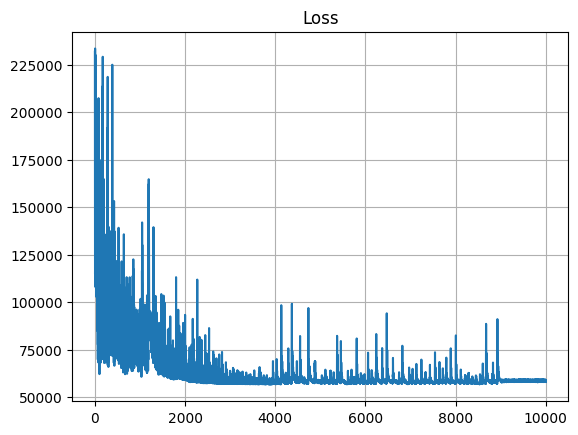

In [9]:
plt.figure()
plt.plot(model.pyro_model.losses)
plt.title('Loss')
plt.grid()
plt.savefig(outpath+'/SVI/SVI_losses.png', dpi=300)

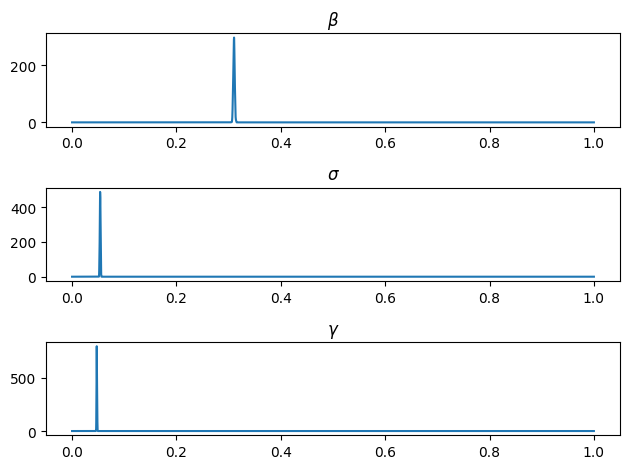

In [12]:
labels = [r'$\beta$', r'$\sigma$', r'$\gamma$']

fig, ax = plt.subplots(3,1)

for j, sample in enumerate([beta_samples, sigma_samples, gamma_samples]) :
    
    kde = stats.gaussian_kde(sample)
    x_lin = np.linspace(0,1,10000)
    ax[j].plot(x_lin, kde(x_lin))
    
    ax[j].set_title(labels[j])
    ax[j].grid

#plt.grid()
plt.tight_layout()
plt.savefig(outpath+'/SVI/SVI_histograms.png', dpi=300)
plt.show()

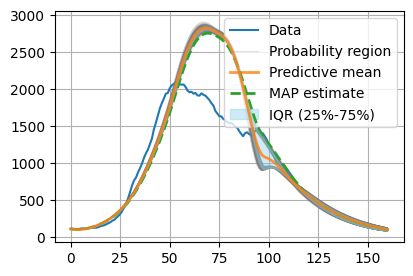

In [13]:
q25 = np.quantile(incidences, 0.25, axis=0)
q75 = np.quantile(incidences, 0.75, axis=0)
median = np.median(incidences, axis=0)
mean_predictive = np.mean(incidences, axis=0)
incidences = np.array(incidences)

plt.figure(figsize=(4.5,3))
plt.plot(times, data, label='Data')
plt.plot(times, incidences.T, alpha=0.2, lw=0.25, color='gray')
plt.plot([], [], alpha=0.2, lw=1, color='gray',label='Probability region')
plt.plot(times, mean_predictive, color='tab:orange', lw=2, alpha=0.8, label='Predictive mean',zorder=11)
plt.plot(times, MAP_curve, '--', color='tab:green', lw=2, label='MAP estimate',zorder=9)
plt.fill_between(times, q25, q75, color="skyblue", alpha=0.4, label="IQR (25%-75%)",zorder=10)
plt.grid()
plt.legend()
plt.savefig(outpath+'/SVI/SVI_probability_region.png',dpi=300)
plt.show()

